#### Name : Muhammad Saad
#### Reg# : SP24-BSE-081
#### Course : Information Security
#### Instructor : Mr.Bilal Hussain
#### Date : 9/10/2026
#### Lab Assignment : 1

# Stream Ciphers and Pseudo Random Generator (PRG)

**Objective:** Understand the working of stream ciphers and PRGs, and implement ARC4 and the Vernam cipher.

**Introduction:** Stream ciphers encrypt data one bit or byte at a time using a pseudo-random keystream. A PRG generates this keystream, which is combined with the plaintext using XOR.

## Activity 1 / Task 1: ARC4 (RC4) Cipher
ARC4 has two parts: the **KSA** (Key Scheduling Algorithm) initializes a 256-byte state from the key, and the **PRGA** (Pseudo-Random Generation Algorithm) outputs one keystream byte per step.

In [1]:
def arc4crypt(data, key):
    # KSA: key scheduling
    x = 0
    box = list(range(256))
    for i in range(256):
        x = (x + box[i] + ord(key[i % len(key)])) % 256
        box[i], box[x] = box[x], box[i]

    # PRGA: keystream generation + XOR
    out = []
    x = y = 0
    for char in data:
        x = (x + 1) % 256
        y = (y + box[x]) % 256
        box[x], box[y] = box[y], box[x]
        out.append(chr(ord(char) ^ box[(box[x] + box[y]) % 256]))
    return "".join(out)

### Test encryption and decryption
The ciphertext contains non-printable characters, so it is displayed as hex.

In [2]:
key = "Key"
plaintext = "Plaintext"

cipher = arc4crypt(plaintext, key)
decrypted = arc4crypt(cipher, key)

print("Plaintext   :", plaintext)
print("Cipher (hex):", cipher.encode("latin-1").hex().upper())
print("Decrypted   :", decrypted)

# Published RC4 test vector for key "Key", plaintext "Plaintext"
assert cipher.encode("latin-1").hex().upper() == "BBF316E8D940AF0AD3"
assert decrypted == plaintext
print("\nTest vector matches and decryption is correct.")

Plaintext   : Plaintext
Cipher (hex): BBF316E8D940AF0AD3
Decrypted   : Plaintext

Test vector matches and decryption is correct.


## Activity 2 / Task 2: Vernam Cipher
XOR of the plaintext with a key. It is a true one-time pad only if the key is random, at least as long as the message, and never reused.

In [3]:
def VernamEncDec(text, key):
    result = ""
    ptr = 0
    for char in text:
        result += chr(ord(char) ^ ord(key[ptr]))
        ptr += 1
        if ptr == len(key):
            ptr = 0
    return result

In [4]:
msg = "HELLO WORLD"
key = "XMCKLQWERTY"          # same length as the message

enc = VernamEncDec(msg, key)
dec = VernamEncDec(enc, key)

print("Encrypted (hex):", enc.encode("latin-1").hex())
print("Decrypted      :", dec)
print("Correct        :", dec == msg)

Encrypted (hex): 10080f070371000a00181d
Decrypted      : HELLO WORLD
Correct        : True


### Caveat: key wrap-around
When the key is shorter than the text the code repeats it, which makes this a repeating-key XOR cipher and breakable. A proper one-time pad uses a random key generated per message:

In [5]:
import secrets

msg = "ATTACK AT DAWN"
# Random key, same length as the message, used once (characters 0-255)
otp = "".join(chr(b) for b in secrets.token_bytes(len(msg)))

enc = VernamEncDec(msg, otp)
print("Key (hex)       :", otp.encode("latin-1").hex())
print("Ciphertext (hex):", enc.encode("latin-1").hex())
print("Decrypted       :", VernamEncDec(enc, otp))

Key (hex)       : 850879c4ee849cc89c1b1ab4fe3d
Ciphertext (hex): c45c2d85adcfbc89c83b5ef5a973
Decrypted       : ATTACK AT DAWN


## Task 3: Role of the PRG in Stream Ciphers

A stream cipher approximates the one-time pad. The OTP needs a truly random key as long as the message, which is impractical. A PRG solves this:

1. **Key expansion:** stretches a short secret seed (128 or 256 bits) into an arbitrarily long keystream.
2. **Encryption:** `C = P XOR keystream`, and `P = C XOR keystream`.
3. **Security requirement:** the keystream must be computationally indistinguishable from random.
4. **Synchronization:** sender and receiver run the same PRG from the same seed.
5. **Never reuse a key (or key+nonce):** if two messages share a keystream, `C1 XOR C2 = P1 XOR P2`, which leaks information.

In ARC4, the KSA initializes the state and the PRGA is the PRG producing one keystream byte per step. The demo below extracts the keystream and shows what happens when it is reused.

In [6]:
def arc4_keystream(key, n):
    """Return n keystream bytes (encrypting zero bytes reveals the keystream)."""
    return arc4crypt("\x00" * n, key).encode("latin-1")

ks = arc4_keystream("Key", 16)
print("Keystream (hex):", ks.hex())

# Same seed -> same keystream (synchronization)
assert ks == arc4_keystream("Key", 16)
# Different seed -> different keystream
print("Different key  :", arc4_keystream("Kez", 16).hex())

Keystream (hex): eb9f7781b734ca72a7194a2867b64295
Different key  : a7c9d8678a1f48ae025ce991d8ce6df8


In [7]:
# Keystream reuse attack demonstration
p1 = "ATTACK AT DAWN"
p2 = "RETREAT AT DUSK"[:len(p1)]
c1 = arc4crypt(p1, "SameKey")
c2 = arc4crypt(p2, "SameKey")   # same key reused: mistake!

# XOR of ciphertexts = XOR of plaintexts; keystream cancels out
xor_c = bytes(ord(a) ^ ord(b) for a, b in zip(c1, c2))
xor_p = bytes(ord(a) ^ ord(b) for a, b in zip(p1, p2))
print("C1 xor C2 == P1 xor P2 :", xor_c == xor_p)

C1 xor C2 == P1 xor P2 : True


## Activity 3 / Task 4: Salsa20 Cipher

Salsa20 (Daniel J. Bernstein) is built only from **Add, Rotate, XOR (ARX)** operations on 32-bit words, so it is fast and resistant to timing attacks (no table lookups).

**Inputs:** 256-bit key, 64-bit nonce, 64-bit block counter, and four 32-bit constants (`"expand 32-byte k"`).

**Steps:**
1. Arrange 16 words (4 constants, 8 key words, 2 nonce words, 2 counter words) in a 4x4 matrix.
2. **Quarter-round** on words (a, b, c, d):
   - `b ^= (a + d) <<< 7`
   - `c ^= (b + a) <<< 9`
   - `d ^= (c + b) <<< 13`
   - `a ^= (d + c) <<< 18`
3. Apply it to each **column**, then each **row**, alternating, for 20 rounds (10 double-rounds).
4. **Feed-forward:** add the original input state to the result word-by-word mod 2^32 (makes the block function non-invertible).
5. The result is a 64-byte keystream block; increment the counter for the next block.
6. XOR the keystream with the plaintext.

The counter allows jumping to any block (random access). The implementation below is for study only.

In [8]:
import struct

M32 = 0xFFFFFFFF
def rotl(v, n): return ((v << n) & M32) | (v >> (32 - n))

def quarterround(a, b, c, d):
    b ^= rotl((a + d) & M32, 7)
    c ^= rotl((b + a) & M32, 9)
    d ^= rotl((c + b) & M32, 13)
    a ^= rotl((d + c) & M32, 18)
    return a, b, c, d

def salsa20_block(key, nonce, counter):
    assert len(key) == 32 and len(nonce) == 8
    const = struct.unpack("<4I", b"expand 32-byte k")
    k = struct.unpack("<8I", key)
    n = struct.unpack("<2I", nonce)
    ctr = (counter & M32, counter >> 32)
    inp = [const[0], k[0], k[1], k[2],
           k[3], const[1], n[0], n[1],
           ctr[0], ctr[1], const[2], k[4],
           k[5], k[6], k[7], const[3]]
    x = inp[:]
    for _ in range(10):                      # 10 double-rounds = 20 rounds
        # column round
        x[0],x[4],x[8],x[12]  = quarterround(x[0],x[4],x[8],x[12])
        x[5],x[9],x[13],x[1]  = quarterround(x[5],x[9],x[13],x[1])
        x[10],x[14],x[2],x[6] = quarterround(x[10],x[14],x[2],x[6])
        x[15],x[3],x[7],x[11] = quarterround(x[15],x[3],x[7],x[11])
        # row round
        x[0],x[1],x[2],x[3]     = quarterround(x[0],x[1],x[2],x[3])
        x[5],x[6],x[7],x[4]     = quarterround(x[5],x[6],x[7],x[4])
        x[10],x[11],x[8],x[9]   = quarterround(x[10],x[11],x[8],x[9])
        x[15],x[12],x[13],x[14] = quarterround(x[15],x[12],x[13],x[14])
    out = [(x[i] + inp[i]) & M32 for i in range(16)]   # feed-forward
    return struct.pack("<16I", *out)

def salsa20_crypt(data: bytes, key: bytes, nonce: bytes) -> bytes:
    out = bytearray()
    for i in range(0, len(data), 64):
        block = salsa20_block(key, nonce, i // 64)
        out.extend(b ^ k for b, k in zip(data[i:i+64], block))
    return bytes(out)

# Check quarter-round against the example in the Salsa20 specification
assert quarterround(1, 0, 0, 0) == (0x08008145, 0x80, 0x10200, 0x20500000)
print("Quarter-round matches the Salsa20 specification example.")

Quarter-round matches the Salsa20 specification example.


In [9]:
key = bytes(range(32))
nonce = bytes(8)
msg = b"Salsa20 is an ARX stream cipher."

ct = salsa20_crypt(msg, key, nonce)
print("Ciphertext (hex):", ct.hex())
print("Decrypted       :", salsa20_crypt(ct, key, nonce))

Ciphertext (hex): e6e19b147d44d5d72d69d81d7a4d2a036130afff33238e761272a662c72f3967
Decrypted       : b'Salsa20 is an ARX stream cipher.'


## Task 5: Comparison and Performance
First, a quick timing benchmark of the three implementations (pure Python, so absolute numbers are only indicative; real implementations in C are far faster).

In [10]:
import time, os

size = 100_000   # bytes
text = "".join(chr(b) for b in os.urandom(size))
vkey = "".join(chr(b) for b in os.urandom(size))   # OTP key as long as the data
rc4key = "SecretKey"
skey, snonce = os.urandom(32), os.urandom(8)
raw = text.encode("latin-1")

def timeit(f):
    t = time.perf_counter(); f(); return time.perf_counter() - t

t_rc4 = timeit(lambda: arc4crypt(text, rc4key))
t_ver = timeit(lambda: VernamEncDec(text, vkey))
t_sal = timeit(lambda: salsa20_crypt(raw, skey, snonce))

print(f"Data size: {size} bytes")
print(f"ARC4    : {t_rc4:.3f} s")
print(f"Vernam  : {t_ver:.3f} s  (but needs a {size}-byte key)")
print(f"Salsa20 : {t_sal:.3f} s")

Data size: 100000 bytes
ARC4    : 0.052 s
Vernam  : 0.041 s  (but needs a 100000-byte key)
Salsa20 : 0.410 s


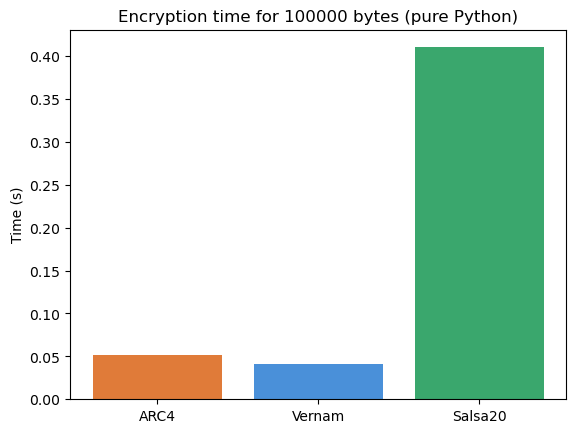

In [11]:
import matplotlib.pyplot as plt

plt.bar(["ARC4", "Vernam", "Salsa20"], [t_rc4, t_ver, t_sal], color=["#e07b39", "#4a90d9", "#3aa76d"])
plt.ylabel("Time (s)")
plt.title(f"Encryption time for {size} bytes (pure Python)")
plt.show()

### Comparison table

| Feature | ARC4 (RC4) | Vernam Cipher (OTP) | Salsa20 |
|---|---|---|---|
| Key size | 40-2048 bits (typically 128) | Equal to message length | 256 bits (also 128) |
| Keystream source | KSA + PRGA (state permutation) | The key itself (truly random) | ARX hash function in counter mode |
| Nonce/IV | None built in | None | 64-bit nonce + 64-bit counter |
| Security | **Broken/deprecated**: biased initial bytes, key-recovery attacks (e.g. WEP); prohibited in TLS | **Perfect secrecy** if key is random, as long as the message, and used once | Strong; no practical attacks on full 20 rounds |
| Practicality | Easy key handling | Very poor: key distribution and storage as hard as the message | Practical and widely used (ChaCha20 variant is in TLS 1.3) |
| Performance | Fast in software, simple | One XOR per byte, but needs a huge key | Very fast, SIMD-friendly, constant-time |
| Main weakness | Statistical biases, no nonce | Key reuse or non-random key destroys security | Nonce must never repeat with the same key |

## Conclusion
The Vernam cipher offers the best theoretical security but is impractical. ARC4 is simple and fast but no longer safe. Salsa20 (or ChaCha20) combines strong security with high speed and is the right choice for modern applications.